In [1]:
%load_ext autoreload
%autoreload 2

In [9]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.cuda.is_available())

import matplotlib.pyplot as plt
from dataset import MOViC_Dataset
from torchvision import transforms
from torchvision.transforms import (
    RandomHorizontalFlip,
    RandomVerticalFlip,
    RandomRotation,
    ColorJitter,
    ToTensor,
    Resize
)
import numpy as np

import imageio
from io import BytesIO
from IPython.display import display, Image as IPImage
from PIL import Image

True


In [3]:
DATASET_PATH = '/home/nfs/inf6/data/datasets/MOVi/movi_c'

### Test of dataset transformations

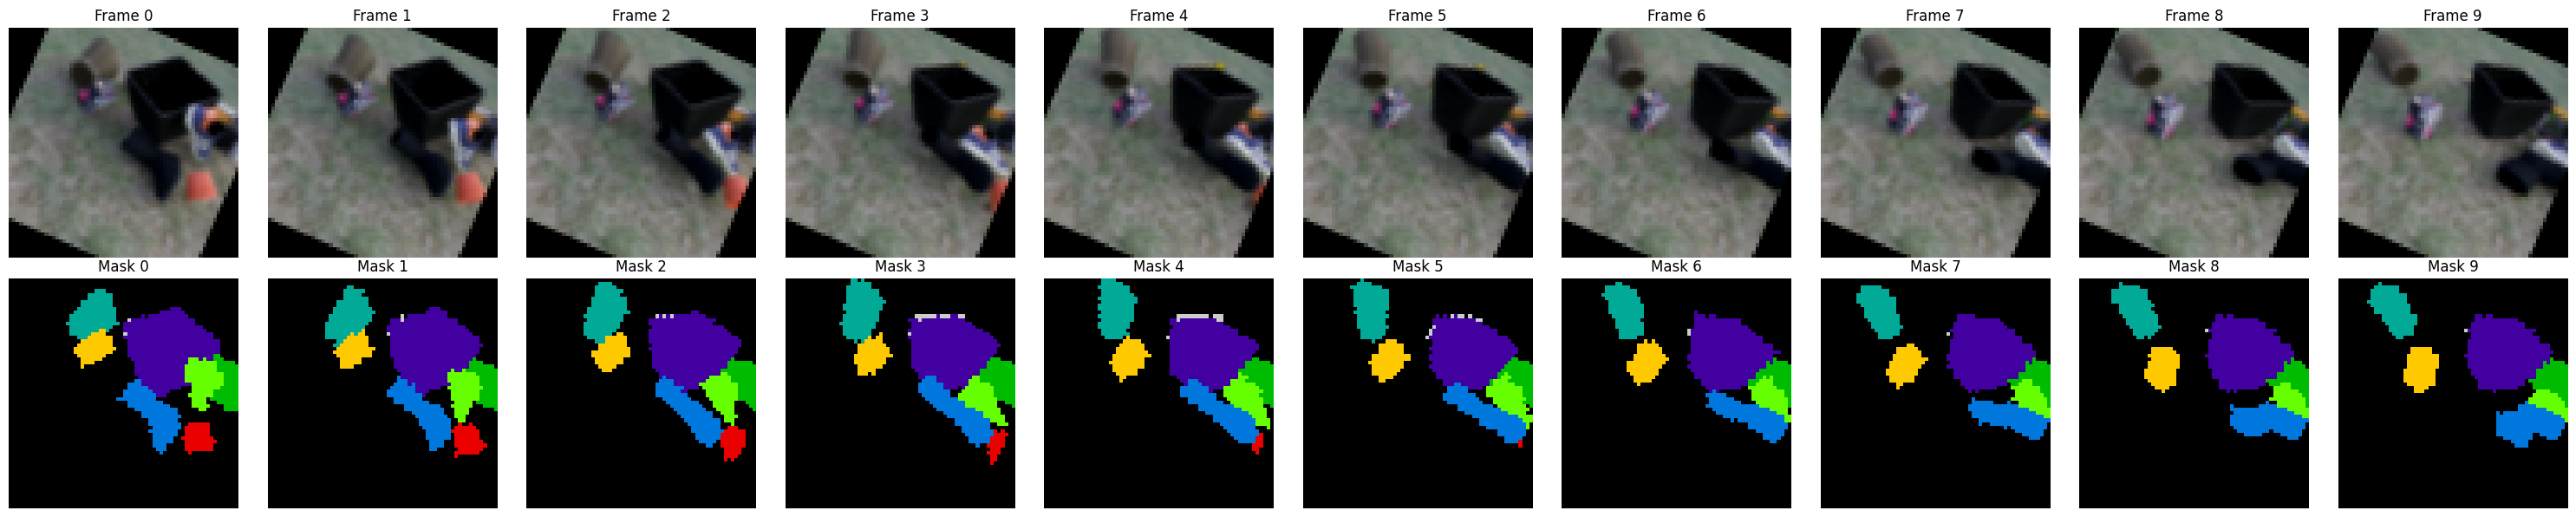

In [4]:
train_transform = transforms.Compose([
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=(-30, 30)),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    )
])
dataset = MOViC_Dataset(root_dir=DATASET_PATH, split="train", target="objects", img_size=(64, 64), transform=train_transform)
sample = dataset[2]

def show_frames_and_masks(sample, n=5, cmap="tab20"):
    """
    sample: [(frame, mask), ...]
    n: how many frames to show
    """
    fig, axes = plt.subplots(2, n, figsize=(3*n, 6))
    cmap = plt.get_cmap(cmap)

    for i, (frame, mask) in enumerate(sample[:n]):
        frame = frame.permute(1, 2, 0).numpy()  # CHW -> HWC
        mask = mask.squeeze().numpy().astype(int)

        axes[0, i].imshow(frame)
        axes[0, i].set_title(f"Frame {i}")
        axes[0, i].axis("off")

        axes[1, i].imshow(mask, cmap=cmap, interpolation="nearest")
        axes[1, i].set_title(f"Mask {i}")
        axes[1, i].axis("off")

    plt.tight_layout()
    plt.show()

show_frames_and_masks(sample, n=10, cmap="nipy_spectral")

In [5]:
def visualize_frames_as_gif(frames, fps: int = 5, scale: float = 1.0, width: int | None = None, height: int | None = None):
    images = []
    if isinstance(frames, torch.Tensor):
        if frames.ndim == 4 and frames.shape[1] in (1,3):
            frames = frames.permute(0,2,3,1).cpu().numpy()
        for f in frames:
            arr = (f * 255).clip(0,255).astype("uint8")
            img = Image.fromarray(arr)
            # масштаб
            w, h = img.size
            if width and height:
                img = img.resize((width, height), Image.NEAREST)
            elif scale != 1.0:
                img = img.resize((int(w*scale), int(h*scale)), Image.NEAREST)
            images.append(img)

    with BytesIO() as buffer:
        imageio.mimsave(buffer, images, format="GIF", duration=1/fps)
        buffer.seek(0)
        display(IPImage(data=buffer.getvalue()))

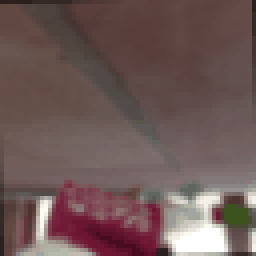

In [24]:
visualize_frames_as_gif(new_sample, fps=1, scale=4)

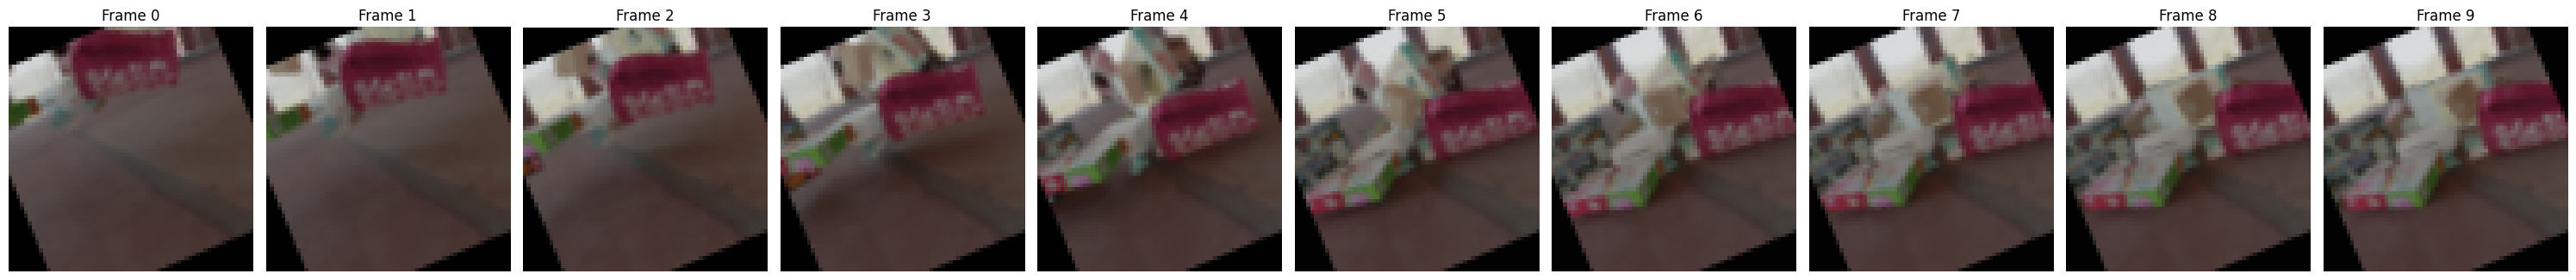

In [40]:
dataset = MOViC_Dataset(root_dir=DATASET_PATH, split="train", target="rgb", img_size=(64, 64), transform=train_transform)
new_sample = dataset[5] # list [frame1, frame2, ...]

def show_frames_and_masks(sample, n=5, cmap="tab20"):
    """
    sample: [(frame, mask), ...]
    n: сколько кадров показать
    """
    fig, axes = plt.subplots(1, n, figsize=(3*n, 6))
    cmap = plt.get_cmap(cmap)

    for i, frame in enumerate(sample[:n]):
        frame = frame.permute(1, 2, 0).numpy()  # CHW -> HWC
        # верхняя строка: кадры
        axes[i].imshow(frame)
        axes[i].set_title(f"Frame {i}")
        axes[i].axis("off")
    

    plt.tight_layout()
    plt.show()

show_frames_and_masks(new_sample, n=10, cmap="nipy_spectral")

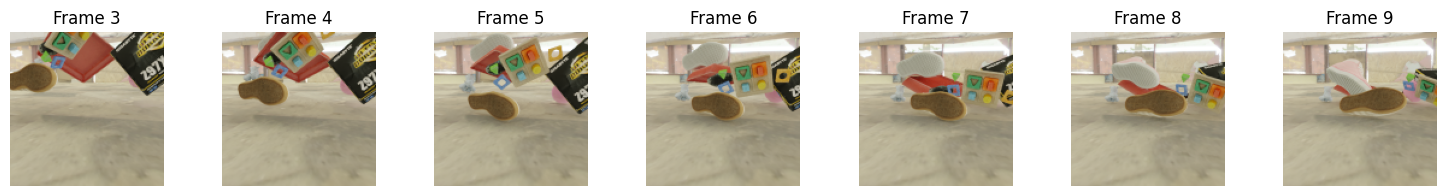

In [17]:
from utils.display_frame_sequence import display_frame_sequence

display_frame_sequence(f"{DATASET_PATH}/validation", video_id=144, num_frames=10, start_frame=3)

### Transformer test

In [44]:
from save_load import load_model
from models.autoencoder import ImageAutoencoder
from models.encoder import ViTPatchEncoder
from models.decoder import ViTPatchDecoder

PATCH_SIZE = 16

encoder = ViTPatchEncoder(patch_size=PATCH_SIZE,
                          embed_dim=256,
                          max_len=(64 // PATCH_SIZE) * (64 // PATCH_SIZE),
                          attn_dim=128,
                          num_heads=4,
                          mlp_size=512,
                          num_tf_layers=4)

decoder = ViTPatchDecoder(patch_size=PATCH_SIZE,
                          H = 64,
                          W = 64,
                          embed_dim=256,
                          max_len=(64 // PATCH_SIZE) * (64 // PATCH_SIZE),
                          attn_dim=128,
                          num_heads=4,
                          mlp_size=512,
                          num_tf_layers=4)

autoencoder_img = ImageAutoencoder(encoder, decoder)

model_path = 'experiments/14-09-2025_00-31_TransformerPatch_AE/checkpoints'
autoencoder_img, _, _ = load_model(autoencoder_img, None, 'epoch_005_iter_36515', model_path)

encoder, decoder = autoencoder_img.encoder, autoencoder_img.decoder

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.05455175..0.72995436].


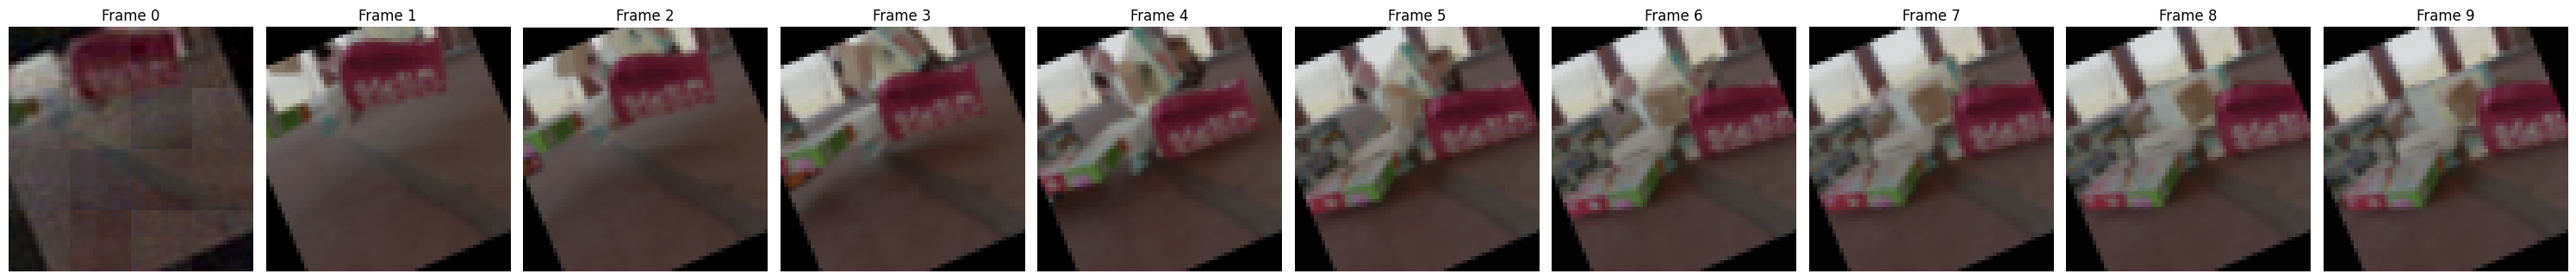

In [43]:
show_frames_and_masks(new_sample.detach(), n=10, cmap="nipy_spectral")

In [54]:
from models.vpt import VideoARTransformer

model = VideoARTransformer(
    encoder=encoder,
    decoder=decoder,
    H=64, W=64,
    patch_size=PATCH_SIZE,
    embed_dim=256,
    attn_dim=64,
    num_heads=4,
    mlp_size=128,
    num_tf_layers_ar=2
)

print(new_sample.unsqueeze(0)[:,:-1,:,:,:].shape)
# прогон
with torch.no_grad():
    y = model(new_sample.unsqueeze(0)[:,:-1,:,:,:])

print("Input shape :", new_sample.shape)
print("Output shape:", y.shape)

for name, param in model.named_parameters():
    print(f"{name:60} | requires_grad = {param.requires_grad}")


torch.Size([1, 9, 3, 64, 64])
Input shape : torch.Size([10, 3, 64, 64])
Output shape: torch.Size([1, 9, 3, 64, 64])
encoder.patch_projection.0.weight                            | requires_grad = False
encoder.patch_projection.0.bias                              | requires_grad = False
encoder.patch_projection.1.weight                            | requires_grad = False
encoder.patch_projection.1.bias                              | requires_grad = False
encoder.transformer_blocks.0.ln_att.weight                   | requires_grad = False
encoder.transformer_blocks.0.ln_att.bias                     | requires_grad = False
encoder.transformer_blocks.0.attn.q.weight                   | requires_grad = False
encoder.transformer_blocks.0.attn.k.weight                   | requires_grad = False
encoder.transformer_blocks.0.attn.v.weight                   | requires_grad = False
encoder.transformer_blocks.0.attn.out_proj.weight            | requires_grad = False
encoder.transformer_blocks.0.ln_ml

In [45]:
from dataset import MOViC_Dataset
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# допустим, у тебя есть класс MOViC_Dataset
dataset = MOViC_Dataset(
    root_dir=DATASET_PATH,
    split="train",
    target='mask',  # или 'mask'
    img_size=(64, 64),
    input_frames=5,
    target_frames=5,
    transform=transforms.Compose([
        transforms.RandomVerticalFlip(),
        #transforms.ColorJitter(brightness=0.8, contrast=0.9)
    ])
)



torch.Size([5, 64, 64]) torch.Size([5, 64, 64])


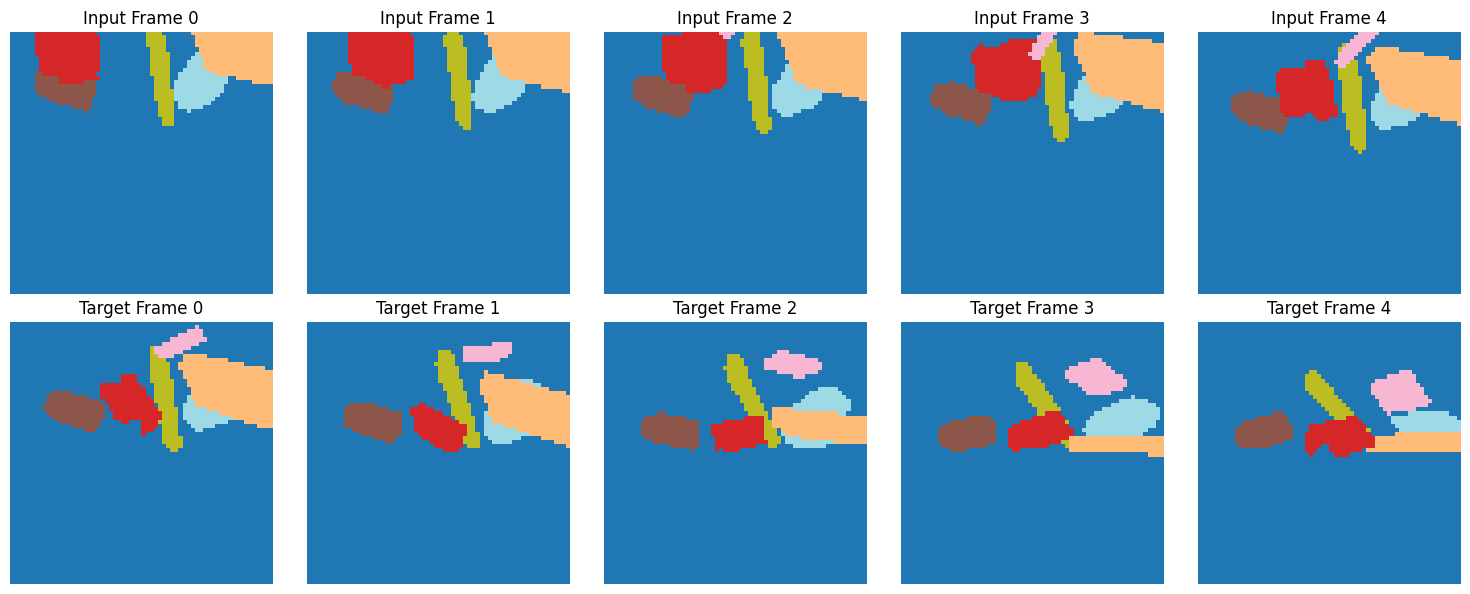

In [47]:
# Получаем пример из датасета
input_frames, target_frames = dataset[4]  # оба размера: [5, 1, H, W]

n_input = input_frames.shape[0]
n_target = target_frames.shape[0]
n_total = max(n_input, n_target)

fig, axs = plt.subplots(2, n_total, figsize=(3 * n_total, 6))

for i in range(n_total):
    # --- Input mask ---
    if i < n_input:
        mask = input_frames[i]  # [1, H, W] или [H, W]
        if mask.ndim == 3:
            mask = mask.squeeze(0)
        axs[0, i].imshow(mask.numpy(), cmap="tab20", vmin=0)
        axs[0, i].set_title(f"Input Frame {i}")
        axs[0, i].axis("off")

    # --- Target mask ---
    if i < n_target:
        mask = target_frames[i]
        if mask.ndim == 3:
            mask = mask.squeeze(0)
        axs[1, i].imshow(mask.numpy(), cmap="tab20", vmin=0)
        axs[1, i].set_title(f"Target Frame {i}")
        axs[1, i].axis("off")

plt.tight_layout()
plt.show()

In [30]:
dataset[0]

torch.Size([5, 64, 64]) torch.Size([5, 64, 64])


(tensor([[[0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          ...,
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0]],
 
         [[0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          ...,
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0]],
 
         [[0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          ...,
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0]],
 
         [[0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          ...,
          [0, 0, 2,  ..., 0, 0, 0],
          [0, 0, 2,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0]],
 
         [[0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0,

torch.Size([5, 64, 64]) torch.Size([5, 64, 64])


RuntimeError: permute(sparse_coo): number of dimensions in the tensor input does not match the length of the desired ordering of dimensions i.e. input.dim() = 2 is not equal to len(dims) = 3

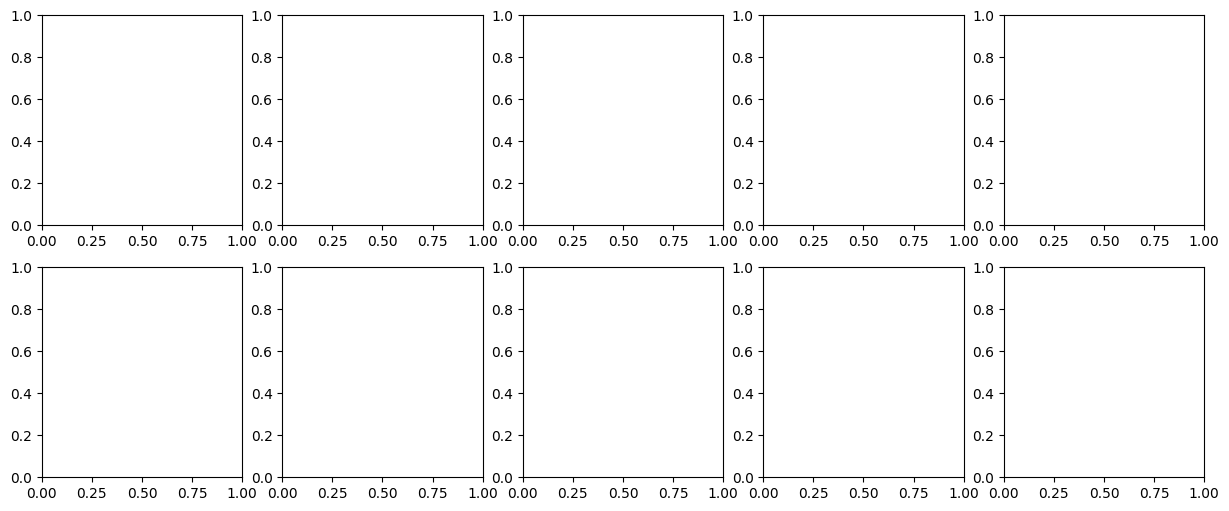

In [31]:
# взять один пример
input_frames, target_frames = dataset[4]

n_input = input_frames.shape[0]
n_target = target_frames.shape[0]
n_total = max(n_input, n_target)

fig, axs = plt.subplots(2, n_total, figsize=(3 * n_total, 6))

for i in range(n_total):
    if i < n_input:
        axs[0, i].imshow(input_frames[i].permute(1, 2, 0).numpy())
        axs[0, i].set_title(f"Input Frame {i}")
    axs[0, i].axis("off")

    if i < n_target:
        axs[1, i].imshow(target_frames[i].permute(1, 2, 0).numpy())
        axs[1, i].set_title(f"Target Frame {i}")
    axs[1, i].axis("off")

plt.tight_layout()
plt.show()

In [20]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
import torch

# configure device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.cuda.is_available())

# define global paths and names
DATASET_PATH = '/home/nfs/inf6/data/datasets/MOVi/movi_c'
TRAIN_PATH = DATASET_PATH + "/train"
VALIDATION_PATH = DATASET_PATH + "/validation"

True


In [22]:
from dataset import ImageDataset
from torchvision import transforms

val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    transforms.ToTensor(),
])

dataset = ImageDataset(VALIDATION_PATH, train_transform)
sample = next(iter(dataset))
print(sample.shape)

torch.Size([3, 64, 64])


(-0.5, 63.5, 63.5, -0.5)

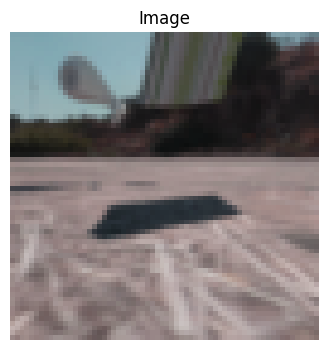

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(sample.permute(1, 2, 0).numpy())
plt.title("Image")
plt.axis("off")

In [24]:
train_dataset = ImageDataset(TRAIN_PATH, train_transform)
val_dataset = ImageDataset(VALIDATION_PATH, val_transform)

In [25]:
from torch.utils.data import DataLoader

B_SIZE = 64

train_loader = DataLoader(
        dataset=train_dataset, 
        batch_size=B_SIZE, 
        shuffle=True,
        num_workers=4
) 
val_loader = DataLoader(
        dataset=val_dataset, 
        batch_size=B_SIZE,
        shuffle=False,
        num_workers=4
)

In [26]:
from models.autoencoder import ImageAutoencoder
from models.encoder import ViTPatchEncoder
from models.decoder import ViTPatchDecoder

PATCH_SIZE = 16
H, W = 64, 64
encoder = ViTPatchEncoder(patch_size=PATCH_SIZE,
                          embed_dim=256,
                          max_len=(64 // PATCH_SIZE) * (64 // PATCH_SIZE),
                          attn_dim=128,
                          num_heads=4,
                          mlp_size=512,
                          num_tf_layers=4)

decoder = ViTPatchDecoder(patch_size=PATCH_SIZE,
                          H = 64,
                          W = 64,
                          embed_dim=256,
                          max_len=(64 // PATCH_SIZE) * (64 // PATCH_SIZE),
                          attn_dim=128,
                          num_heads=4,
                          mlp_size=512,
                          num_tf_layers=4)

autoencoder_img = ImageAutoencoder(encoder, decoder)

In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau
from evaluate import evaluate_autoencoder
from train import Trainer

optimizer = torch.optim.Adam(autoencoder_img.parameters(), lr=1e-3)
criterion = torch.nn.MSELoss()
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

trainer = Trainer(model=autoencoder_img, evaluate=evaluate_autoencoder,
                  optimizer=optimizer, criterion=criterion, scheduler=scheduler, experiment_name="TransformerPatch_AE")
trainer.train(train_loader, val_loader, 10)

Ep 0 Iter 8: Loss=0.11375):   0%|                                                                                          | 0/10 [00:16<?, ?it/s]

{'iter': 0, 'batch_size': 64, 'epoch': 0, 'loss': 1.1505711078643799, 'Loss': 0.5808894710337862, 'SSIM': 0.008875483451701645, 'PSNR': 8.961080028401035}


Ep 0 Iter 1001: Loss=0.02274):   0%|                                                                                       | 0/10 [02:03<?, ?it/s]

{'iter': 1000, 'batch_size': 64, 'epoch': 0, 'loss': 0.02189064584672451, 'Loss': 0.019475927056269125, 'SSIM': 0.5307394198590186, 'PSNR': 18.10210715220142}


Ep 0 Iter 2001: Loss=0.01912):   0%|                                                                                       | 0/10 [03:16<?, ?it/s]

{'iter': 2000, 'batch_size': 64, 'epoch': 0, 'loss': 0.01841278374195099, 'Loss': 0.014059396004898752, 'SSIM': 0.6476225885280861, 'PSNR': 19.580760780414796}


Ep 0 Iter 2761: Loss=0.01463):   0%|                                                                                       | 0/10 [04:00<?, ?it/s]